# Jour 2 · Prévoir avec Prophet, étape par étape

## Objectifs

- comprendre intuitivement ce que Prophet apprend ;
- préparer les colonnes attendues sans perdre le sens temporel ;
- entraîner le modèle sur le passé et prévoir exactement le test ;
- lire une prévision et ses composantes ;
- comparer Prophet à la baseline saisonnière avant de conclure.

## Pourquoi essayer un modèle après la baseline ?

La baseline saisonnière répète une semaine telle quelle. C'est un excellent repère, mais elle ne peut pas :

- adapter progressivement le niveau général ;
- estimer séparément un cycle journalier et un cycle hebdomadaire ;
- lisser le bruit des mesures passées ;
- prolonger une tendance.

Prophet cherche à représenter ces éléments séparément. Nous l'utilisons ici comme un outil pédagogique et pratique, sans démonstration mathématique avancée.

La question reste la même : **ses prévisions sur le futur sont-elles réellement meilleures que notre règle simple ?**

## Le modèle mental de Prophet

Nous pouvons lire son fonctionnement comme une addition :

~~~text
prévision = niveau général + cycle journalier + cycle hebdomadaire + effets connus
~~~

- La **tendance** décrit l'évolution lente du niveau général.
- La **saisonnalité journalière** décrit ce qui revient selon l'heure.
- La **saisonnalité hebdomadaire** distingue par exemple jours ouvrés et week-end.
- Des **événements connus** pourraient représenter des jours fériés ou des arrêts planifiés. Nous n'en ajoutons pas ici.
- Ce que le modèle n'explique pas restera dans les **résidus**, étudiés dans le notebook suivant.

Prophet n'observe pas la température extérieure ni l'état réel de la machine dans cet exemple. Il apprend seulement à partir de la date et de la puissance passée.

![Tendance, saisonnalités journalière et hebdomadaire combinées dans une prévision](../assets/jour_02/02_composantes_prophet.png)

*Le modèle combine plusieurs comportements simples. Cette décomposition aide à expliquer la prévision, mais elle ne garantit pas qu'elle sera meilleure sur le futur.*

## Quand Prophet est-il raisonnable ?

Prophet est particulièrement pratique lorsque :

- les timestamps sont réguliers et suffisamment nombreux ;
- une tendance ou des motifs périodiques sont visibles ;
- on veut obtenir rapidement une prévision interprétable ;
- quelques données manquantes existent, sans détruire tout le signal.

Il sera moins convaincant pour des variations extrêmement rapides, un historique très court, des changements de régime brutaux ou une machine pilotée par des variables externes absentes du modèle.

Ce n'est donc pas « le meilleur modèle de séries temporelles ». C'est une méthode accessible que nous allons évaluer honnêtement.

## Le format demandé : ds et y

Prophet demande un tableau avec deux noms précis :

| Colonne | Contenu | Exemple |
|---|---|---|
| **ds** | date et heure de l'observation | 2026-01-12 08:00:00 |
| **y** | valeur numérique à prévoir | 4,25 kW |

Nos données possèdent déjà ces informations, mais le timestamp se trouve dans l'index et la série s'appelle power_kw. Nous allons uniquement les remettre au format attendu.

Prophet manipule des dates sans information de fuseau. Nous conservons d'abord toutes les données en UTC, puis retirons l'étiquette du fuseau au dernier moment. Cela évite de mélanger accidentellement heure locale et heure UTC.

![Transformation d'un tableau ds et y en prévisions ds et yhat avec Prophet](../assets/jour_02/02_format_prophet_ds_y.png)

*Les couples date-valeur servent à l'apprentissage. Pour les dates futures demandées, Prophet renvoie notamment une valeur prévue appelée yhat.*

## Étape 1 — retrouver exactement le même problème

Nous rechargeons la puissance horaire et réservons les sept derniers jours. Le protocole doit rester identique à celui des baselines : même cible, même frontière et même futur. Sinon, les scores ne seraient pas comparables.

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error


def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "datasets").is_dir():
            return candidate
    raise FileNotFoundError("Dossier datasets introuvable. Lancez Jupyter depuis le projet.")


ROOT = find_project_root()
DATA_DIR = ROOT / "datasets"
plt.style.use("seaborn-v0_8-whitegrid")

df = pd.read_csv(DATA_DIR / "prepared" / "iot_hvac_clean.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
hourly = df.set_index("timestamp")["power_kw"].resample("1h").mean()

cutoff = hourly.index.max() - pd.Timedelta(days=7)
train = hourly.loc[hourly.index <= cutoff]
test = hourly.loc[hourly.index > cutoff]

assert train.index.max() < test.index.min()
assert len(test) == 7 * 24
print(len(train), "heures d'entraînement |", len(test), "heures de test")

C:\Users\bstorm_user\Desktop\time series\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


840 heures d'entraînement | 168 heures de test


C:\Users\bstorm_user\AppData\Local\Temp\ipykernel_89912\2473918478.py:26: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  cutoff = hourly.index.max() - pd.Timedelta(days=7)


## Étape 2 — fabriquer le tableau d'entraînement

Trois transformations suffisent :

1. donner à l'index le nom ds ;
2. donner aux valeurs le nom y ;
3. replacer ds comme colonne avec reset_index.

Nous retirons ensuite le fuseau de ds. Les instants ne changent pas : seule l'information « UTC » disparaît pour respecter le format accepté par Prophet.

In [2]:
prophet_train = (
    train.rename_axis("ds")
    .rename("y")
    .reset_index()
)
prophet_train["ds"] = prophet_train["ds"].dt.tz_localize(None)

print(prophet_train.dtypes)
prophet_train.head()

ds    datetime64[ns]
y            float64
dtype: object


,ds,y
0,2026-07-01 00:00:00,1.30950
1,2026-07-01 01:00:00,1.10350
2,2026-07-01 02:00:00,1.31600
3,2026-07-01 03:00:00,1.20825
4,2026-07-01 04:00:00,1.18950


### Contrôler avant d'entraîner

Le tableau doit contenir uniquement ds et y. La colonne ds doit être de type datetime et y doit être numérique. Vérifiez aussi que la dernière date de prophet_train est bien la frontière d'entraînement, jamais une date du test.

Ce petit contrôle protège contre une erreur fréquente : préparer le tableau avec toute la série, puis croire que le test est encore inconnu.

## Étape 3 — configurer le modèle

| Paramètre | Choix | Pourquoi ? |
|---|---|---|
| daily_seasonality | True | la puissance varie selon l'heure |
| weekly_seasonality | True | semaine et week-end peuvent différer |
| yearly_seasonality | False | six semaines ne suffisent pas pour apprendre une année |
| uncertainty_samples | 0 | accélérer l'atelier ; nous n'affichons pas encore d'intervalle d'incertitude |

Activer une saisonnalité parce qu'elle existe dans l'outil n'est pas une bonne raison. Chaque composante doit correspondre à un motif plausible et à une durée d'historique suffisante.

In [3]:
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    uncertainty_samples=0,
)

model.fit(prophet_train)

07:34:10 - cmdstanpy - INFO - Chain [1] start processing


07:34:10 - cmdstanpy - INFO - Chain [1] done processing


### Que vient de faire fit ?

Le modèle a recherché une tendance et des motifs journaliers et hebdomadaires qui décrivent au mieux **l'entraînement**. Il n'a pas encore vu les vraies valeurs du test.

L'entraînement réussi ne signifie pas que le modèle est bon. Un modèle peut très bien expliquer le passé et échouer sur une nouvelle semaine. Seule l'évaluation suivante nous renseignera.

## Étape 4 — demander les dates du test

Prophet ne devine pas quelles dates nous intéressent. Nous lui transmettons un tableau future contenant exactement les 168 timestamps du test, toujours sans fuseau.

La méthode predict renvoie plusieurs colonnes. La plus importante ici est **yhat**, c'est-à-dire la valeur prévue. Le mot hat signifie traditionnellement « valeur estimée ».

In [4]:
future = pd.DataFrame({
    "ds": test.index.tz_localize(None),
})

forecast = model.predict(future)
forecast[["ds", "yhat", "trend", "daily", "weekly"]].head()

,ds,yhat,trend,daily,weekly
0,2026-08-05 00:00:00,1.954023,2.495696,-0.877965,0.336293
1,2026-08-05 01:00:00,2.010038,2.496142,-0.831105,0.345001
2,2026-08-05 02:00:00,1.891320,2.496587,-0.959694,0.354427
3,2026-08-05 03:00:00,1.727071,2.497033,-1.134355,0.364394
4,2026-08-05 04:00:00,1.712882,2.497478,-1.159318,0.374722


## Étape 5 — réaligner la prévision et mesurer

Prophet a retiré le fuseau pour travailler, mais nos observations de test utilisent encore un index UTC. Nous récupérons donc les valeurs yhat dans une nouvelle série qui reprend exactement l'index de test.

Avant de calculer les métriques, nous vérifions que les longueurs et les timestamps correspondent. Comparer deux tableaux décalés d'une heure produirait un score mathématiquement valide mais pédagogiquement faux.

In [5]:
predicted = pd.Series(
    forecast["yhat"].to_numpy(),
    index=test.index,
    name="Prophet",
)

assert len(predicted) == len(test)
assert predicted.index.equals(test.index)

prophet_mae = mean_absolute_error(test, predicted)
prophet_rmse = math.sqrt(mean_squared_error(test, predicted))

print(f"MAE  : {prophet_mae:.3f} kW")
print(f"RMSE : {prophet_rmse:.3f} kW")

MAE  : 0.828 kW
RMSE : 1.201 kW


### Lire ces deux nombres

La MAE exprime l'erreur absolue moyenne de Prophet en kW. La RMSE augmente davantage si quelques heures sont très mal prévues.

Ces scores n'ont aucune valeur isolément. Ils doivent être comparés à la baseline saisonnière sur les **mêmes 168 heures**. Une amélioration très faible peut ne pas compenser le coût supplémentaire d'installation, d'entraînement, de surveillance et de dépannage du modèle.

![Passé d'entraînement, futur réel et prévision Prophet séparés par une frontière temporelle](../assets/jour_02/02_prevision_prophet.png)

*La zone de test représente un futur que le modèle n'a pas vu. L'écart vertical entre la courbe réelle et la prévision deviendra notre résidu.*

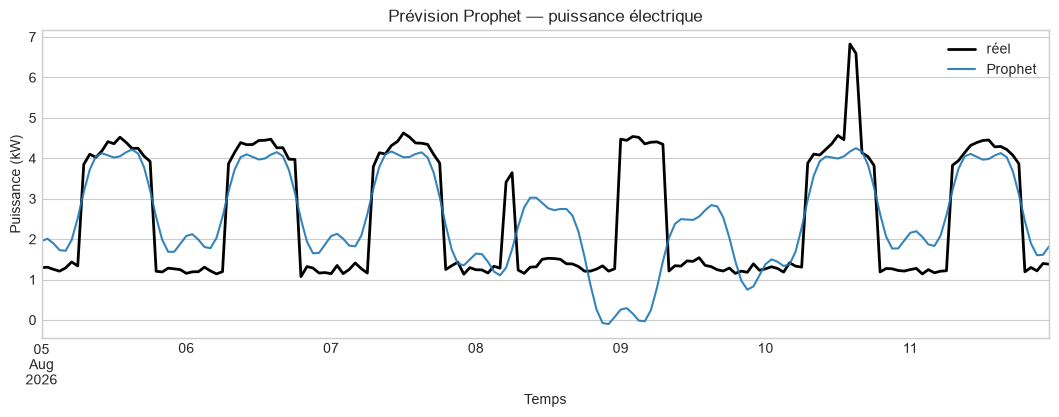

In [6]:
ax = test.plot(figsize=(13, 4), color="black", label="réel", linewidth=2)
predicted.plot(ax=ax, label="Prophet", color="tab:blue", alpha=0.9)
ax.set_title("Prévision Prophet — puissance électrique")
ax.set_ylabel("Puissance (kW)")
ax.set_xlabel("Temps")
ax.legend()
plt.show()

## Étape 6 — lire les composantes

Le graphique des composantes répond à des questions différentes du graphique final :

- **Trend** : le niveau général monte-t-il ou descend-il ?
- **Daily** : à quelles heures le modèle ajoute-t-il ou retire-t-il de la puissance ?
- **Weekly** : quels jours se distinguent de la moyenne ?

L'axe vertical d'une composante représente une contribution au signal, pas directement la puissance complète. Une contribution journalière de +0,5 kW signifie que cette heure ajoute environ 0,5 kW au niveau général estimé.

Attention : une composante est une interprétation construite par le modèle. Elle doit rester cohérente avec le procédé HVAC et avec les observations du Jour 1.

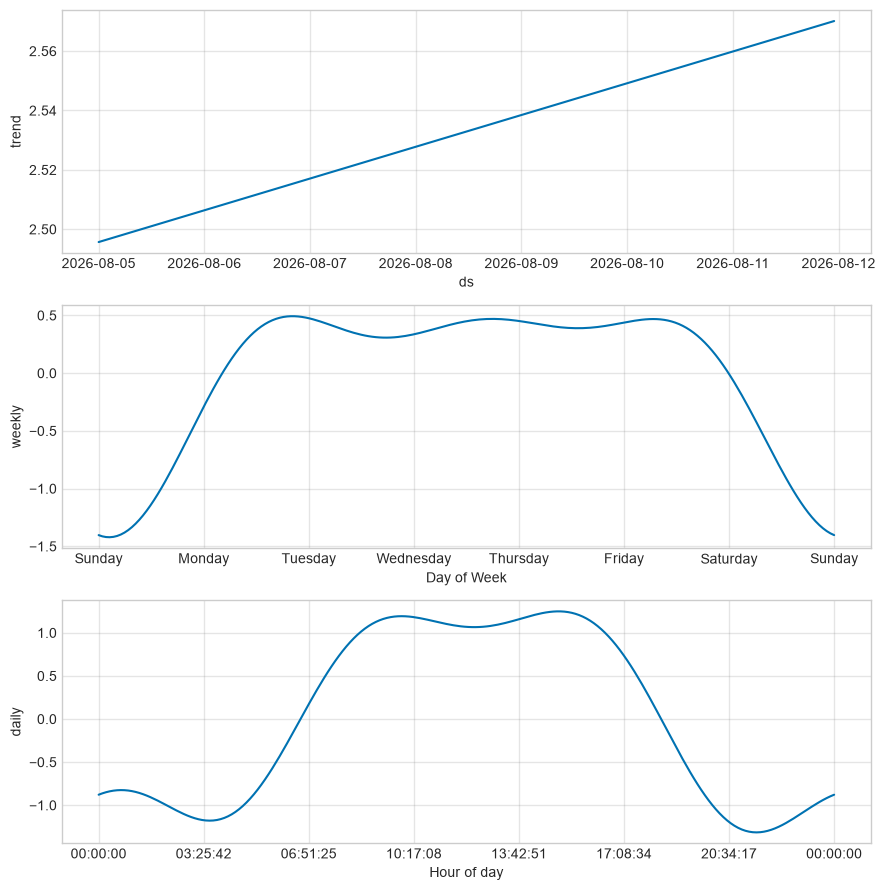

In [7]:
model.plot_components(forecast)
plt.show()

## Étape 7 — remettre la baseline dans la comparaison

Nous reconstruisons la semaine précédente sans réentraîner quoi que ce soit. Le tableau final place les deux approches côte à côte.

Une décision raisonnable ne choisit pas automatiquement le score le plus bas. Elle considère aussi l'écart de performance, la facilité d'explication, le temps de calcul et la maintenance en production.

In [8]:
last_week_pattern = train.iloc[-24 * 7:].to_numpy()
seasonal_naive = pd.Series(
    np.resize(last_week_pattern, len(test)),
    index=test.index,
    name="baseline saisonnière",
)

def evaluate(y_true, y_pred):
    return {
        "MAE (kW)": mean_absolute_error(y_true, y_pred),
        "RMSE (kW)": math.sqrt(mean_squared_error(y_true, y_pred)),
    }

comparison = pd.DataFrame({
    "baseline saisonnière": evaluate(test, seasonal_naive),
    "Prophet": evaluate(test, predicted),
}).T

comparison.round(3)

,MAE (kW),RMSE (kW)
baseline saisonnière,0.434,1.084
Prophet,0.828,1.201


### Une grille de décision simple

| Résultat observé | Décision possible |
|---|---|
| Prophet est moins bon | conserver la baseline et diagnostiquer le modèle |
| gain minuscule | préférer éventuellement la solution la plus simple |
| gain net et stable | poursuivre l'évaluation de Prophet |
| MAE meilleure mais RMSE pire | inspecter les grosses erreurs |
| composantes incohérentes | vérifier les données et les hypothèses |

Avec un seul découpage, notre conclusion reste provisoire. Dans un projet réel, nous testerions plusieurs frontières temporelles successives.

### À vous de jouer — inspecter les plus grandes erreurs

Créez un tableau contenant réel, prévision, erreur signée et erreur absolue. Affichez les dix heures les moins bien prévues.

**Contrôles attendus :** le tableau possède 168 lignes ; erreur signée est positive lorsque Prophet sous-estime ; erreur absolue ne contient aucune valeur négative.

**Indice :** utilisez nlargest sur la colonne d'erreur absolue.

In [9]:
# Écrivez votre code ici.
pass

### À vous de jouer — expliquer une composante

Observez le graphique journalier produit par Prophet. Repérez les heures où la contribution est la plus forte et la plus faible. Proposez une explication HVAC plausible, puis indiquez quelle information externe permettrait de la vérifier.

Une bonne réponse distingue ce que montre le modèle de ce que l'on sait réellement du bâtiment.

In [10]:
# Notez ici votre interprétation sous forme de commentaires.
pass

### À vous de jouer — tester une hypothèse

Entraînez un second modèle sans saisonnalité hebdomadaire. Comparez sa MAE, sa RMSE et sa courbe au modèle complet.

**Question :** la composante hebdomadaire apporte-t-elle une information utile ou seulement de la complexité ?

**Contrôle attendu :** les deux modèles utilisent exactement le même entraînement et le même test.

In [11]:
# Écrivez votre code ici.
pass

## À retenir

- Prophet combine une tendance et des saisonnalités interprétables.
- Le format ds/y est une convention d'entrée, pas une nouvelle information.
- Le modèle apprend uniquement sur le passé fourni à fit.
- yhat est la valeur prévue pour chaque date demandée.
- Les composantes aident à comprendre le modèle, mais le score sur le futur décide de son utilité.
- Prophet doit battre une baseline sur le même test pour justifier sa complexité.

### Mini-mémo du pipeline

~~~text
série horaire → découpage temporel → format ds/y → fit sur train
              → predict sur les dates de test → réalignement → métriques
              → comparaison à la baseline → interprétation
~~~